In [1]:
# Cell 1: Import libraries + load the dataset
import pandas as pd
import numpy as np

# Update this path if needed
DATA_PATH = "flood.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Shape: (50000, 21)
Columns: ['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement', 'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality', 'Siltation', 'AgriculturalPractices', 'Encroachments', 'IneffectiveDisasterPreparedness', 'DrainageSystems', 'CoastalVulnerability', 'Landslides', 'Watersheds', 'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss', 'InadequatePlanning', 'PoliticalFactors', 'FloodProbability']


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,...,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,...,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,...,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,...,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,...,7,6,5,3,3,4,4,3,4,0.475


In [2]:
# Cell 2: Quick structural check (dtypes, missing values, duplicates)
print("Data types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Data types:
MonsoonIntensity                     int64
TopographyDrainage                   int64
RiverManagement                      int64
Deforestation                        int64
Urbanization                         int64
ClimateChange                        int64
DamsQuality                          int64
Siltation                            int64
AgriculturalPractices                int64
Encroachments                        int64
IneffectiveDisasterPreparedness      int64
DrainageSystems                      int64
CoastalVulnerability                 int64
Landslides                           int64
Watersheds                           int64
DeterioratingInfrastructure          int64
PopulationScore                      int64
WetlandLoss                          int64
InadequatePlanning                   int64
PoliticalFactors                     int64
FloodProbability                   float64
dtype: object

Missing values per column:
MonsoonIntensity                   0
Topogr

In [3]:
# Cell 3: Basic cleaning (drop duplicates, standardize column names, sanity checks)
# 1) Drop duplicate rows (if any)
df = df.drop_duplicates().reset_index(drop=True)

# 2) Standardize column names (trim spaces; keep original style but safer)
df.columns = [c.strip() for c in df.columns]

# 3) Ensure target column exists
TARGET_COL = "FloodProbability"
assert TARGET_COL in df.columns, f"Target column '{TARGET_COL}' not found!"

print("After cleaning shape:", df.shape)


After cleaning shape: (50000, 21)


In [4]:
# Cell 4: Validate numeric columns
# Convert everything to numeric where possible (non-convertible becomes NaN)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Re-check missing values after coercion
missing_after = df.isna().sum().sum()
print("Total missing after numeric coercion:", missing_after)

# If any NaNs appeared, decide a strategy (here: drop rows with NaN)
if missing_after > 0:
    df = df.dropna().reset_index(drop=True)
    print("Dropped rows with NaN. New shape:", df.shape)


Total missing after numeric coercion: 0


In [5]:
# Cell 5: Outlier Detection & Removal using IQR Method

# We will apply IQR method column-wise and remove rows containing outliers

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Keep rows where ALL values are within bounds
df_before = df.shape[0]

df = df[~((df < lower_bound) | (df > upper_bound)).any(axis=1)].reset_index(drop=True)

df_after = df.shape[0]

print("Rows before outlier removal:", df_before)
print("Rows after outlier removal:", df_after)
print("Number of rows removed:", df_before - df_after)


Rows before outlier removal: 50000
Rows after outlier removal: 37791
Number of rows removed: 12209


In [6]:
# Final check after preprocessing

print("Final dataset shape after preprocessing:", df.shape)

print("\nNumber of features (including target):", df.shape[1])
print("Number of samples:", df.shape[0])

df.head()


Final dataset shape after preprocessing: (37791, 21)

Number of features (including target): 21
Number of samples: 37791


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,...,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,...,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,...,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,...,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,...,7,6,5,3,3,4,4,3,4,0.475


In [7]:
# Cell 8: Descriptive Statistics

print("Descriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
count,37791.000000,37791.000000,37791.000000,37791.000000,37791.000000,37791.000000,37791.000000,37791.000000,37791.000000,37791.000000,...,37791.000000,37791.000000,37791.000000,37791.000000,37791.000000,37791.000000,37791.000000,37791.000000,37791.000000,37791.000000
mean,4.903125,4.885978,4.922865,4.910296,4.899976,4.913498,4.914927,4.888069,4.920113,4.924135,...,4.907518,4.902834,4.901776,4.890688,4.903284,4.895398,4.913286,4.905216,4.900585,0.490610
std,2.104798,2.113163,2.107599,2.087551,2.108639,2.097657,2.110405,2.102686,2.108726,2.111433,...,2.097036,2.113486,2.112648,2.098484,2.112122,2.101031,2.107678,2.104409,2.112310,0.046599
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.360000
25%,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,0.460000
50%,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,0.490000
75%,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,...,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,0.520000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,...,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,0.640000


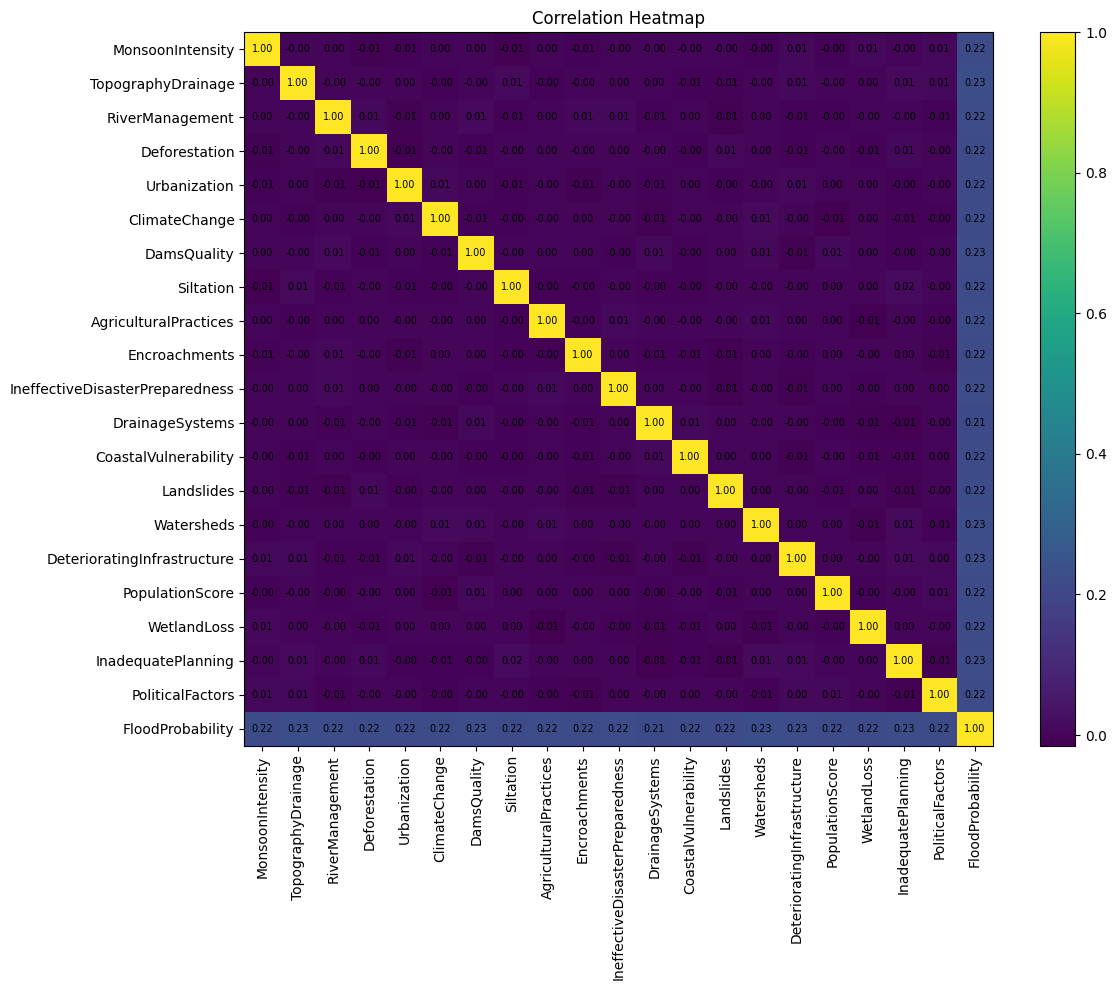

In [8]:
# Cell 9: Correlation Heatmap (annot=True)

import matplotlib.pyplot as plt

corr = df.corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

# Annotate values
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha="center", va="center", fontsize=7)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


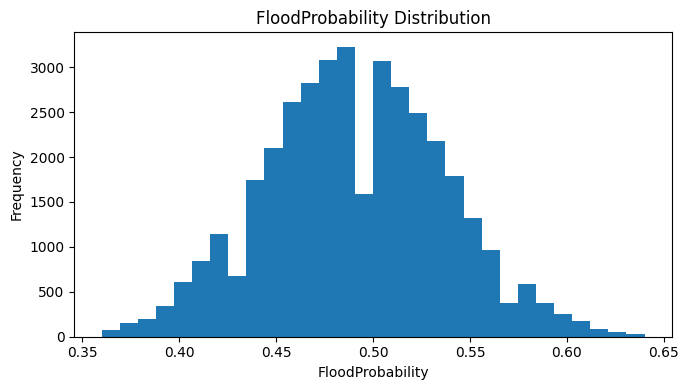

In [9]:
# Cell 10: Target Distribution

plt.figure(figsize=(7, 4))
plt.hist(df["FloodProbability"], bins=30)
plt.title("FloodProbability Distribution")
plt.xlabel("FloodProbability")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


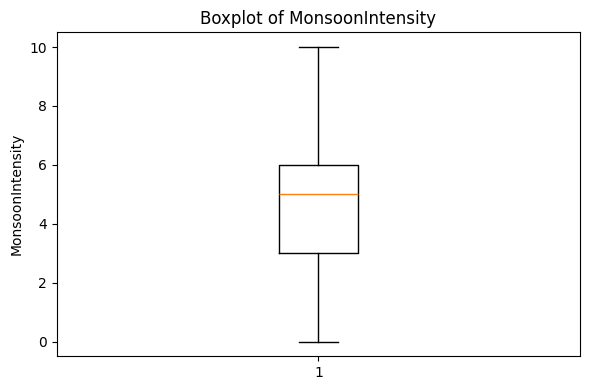

In [10]:
# Boxplot for a Single Column

import matplotlib.pyplot as plt

column_name = "MonsoonIntensity"   # change column here if needed

plt.figure(figsize=(6, 4))
plt.boxplot(df[column_name], showfliers=True)

plt.title(f"Boxplot of {column_name}")
plt.ylabel(column_name)

plt.tight_layout()
plt.show()


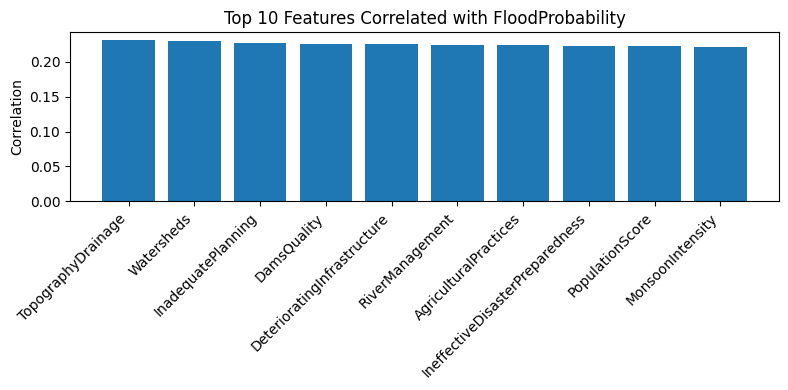

In [11]:
# Cell 12: Top 10 Correlated Features with Target

corr = df.corr()
target_corr = (
    corr["FloodProbability"]
    .drop("FloodProbability")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 4))
plt.bar(target_corr.index, target_corr.values)
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Features Correlated with FloodProbability")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()


/tmp/ipython-input-1013702891.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("Urbanization_Level")["FloodProbability"].mean()


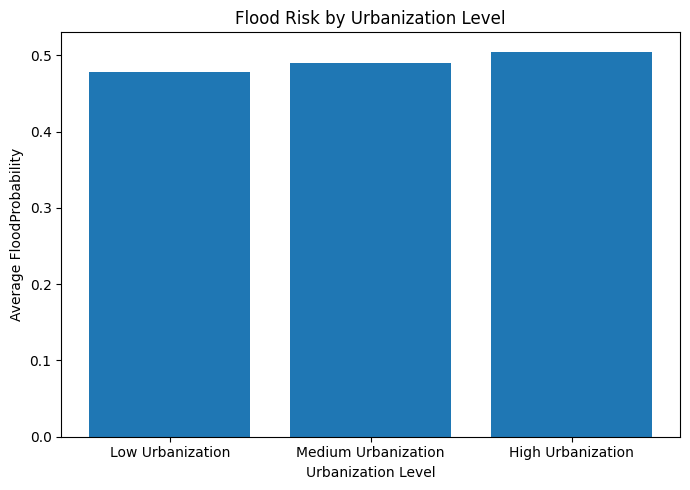

In [12]:
# Meaningful Plot: Flood Risk by Urbanization Level

import matplotlib.pyplot as plt
import pandas as pd

# Create categorical levels for Urbanization
df["Urbanization_Level"] = pd.cut(
    df["Urbanization"],
    bins=3,
    labels=["Low Urbanization", "Medium Urbanization", "High Urbanization"]
)

# Compute average FloodProbability per level
grouped = df.groupby("Urbanization_Level")["FloodProbability"].mean()

plt.figure(figsize=(7, 5))
plt.bar(grouped.index, grouped.values)

plt.xlabel("Urbanization Level")
plt.ylabel("Average FloodProbability")
plt.title("Flood Risk by Urbanization Level")

plt.tight_layout()
plt.show()


In [17]:
# Remove visualization-only column
if "Urbanization_Level" in df.columns:
    df = df.drop(columns=["Urbanization_Level"])
    print("Urbanization_Level removed.")

# create X and y
X = df.drop("FloodProbability", axis=1)
y = df["FloodProbability"]

print("Current feature shape:", X.shape)

Urbanization_Level removed.
Current feature shape: (37791, 20)


In [18]:
# Cell 14: Label Encoding (only if categorical columns exist)

from sklearn.preprocessing import LabelEncoder

categorical_cols = X.select_dtypes(include=["object"]).columns
print("Categorical columns found:", list(categorical_cols))

le = LabelEncoder()
for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

print("Label encoding done .")

Categorical columns found: []
Label encoding done .


In [19]:
# Cell 15: Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

X_train: (30232, 20) X_test: (7559, 20)
y_train: (30232,) y_test: (7559,)


In [20]:
# Cell 16: Standard Scaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on train, transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)

Scaling complete.
Scaled X_train shape: (30232, 20)
Scaled X_test shape: (7559, 20)


In [29]:
# ------------------------------------------------------------
# Support Vector Regression (SVR)
# A nonlinear regression model that finds the best curve
# fitting the relationship between input features and flood risk
# ------------------------------------------------------------

from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Create the SVR model
svr = SVR(kernel="rbf", C=10, epsilon=0.01)

# Train the model using training data
svr.fit(X_train_scaled, y_train)

# Predict flood probability on unseen test data
y_pred_svr = svr.predict(X_test_scaled)

# Evaluate performance
print("------ SVR Regressor ------")
print("R2 Score:", r2_score(y_test, y_pred_svr))
print("MAE:", mean_absolute_error(y_test, y_pred_svr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_svr)))

------ SVR Regressor ------
R2 Score: 0.9864792332290071
MAE: 0.003912355692525548
RMSE: 0.005451838977442457


In [30]:
# ------------------------------------------------------------
# Random Forest Regressor
# Uses many decision trees and averages their predictions
# Good at handling complex environmental relationships
# ------------------------------------------------------------

from sklearn.ensemble import RandomForestRegressor

# Create the model
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_rf = rf.predict(X_test_scaled)

# Evaluate performance
print("\n------ Random Forest Regressor ------")
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))


------ Random Forest Regressor ------
R2 Score: 0.7318160011770494
MAE: 0.01932792366715172
RMSE: 0.024280565124945985


In [31]:
# ------------------------------------------------------------
# XGBoost Regressor
# Advanced boosting algorithm that corrects previous errors
# Often provides the best accuracy in prediction problems
# ------------------------------------------------------------

from xgboost import XGBRegressor

# Create the model
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train the model
xgb.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_xgb = xgb.predict(X_test_scaled)

# Evaluate performance
print("\n------ XGBoost Regressor ------")
print("R2 Score:", r2_score(y_test, y_pred_xgb))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))


------ XGBoost Regressor ------
R2 Score: 0.9555239084399745
MAE: 0.007770096662420181
RMSE: 0.009887936468992714


In [32]:
# ------------------------------------------------------------
# Compare performance of all models in one table
# ------------------------------------------------------------

import pandas as pd

results = pd.DataFrame({
    "Model": ["SVR", "Random Forest", "XGBoost"],
    "R2 Score": [
        r2_score(y_test, y_pred_svr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb)
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_svr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_xgb)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_svr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    ]
})

results

,Model,R2 Score,MAE,RMSE
0,SVR,0.986479,0.003912,0.005452
1,Random Forest,0.731816,0.019328,0.024281
2,XGBoost,0.955524,0.007770,0.009888


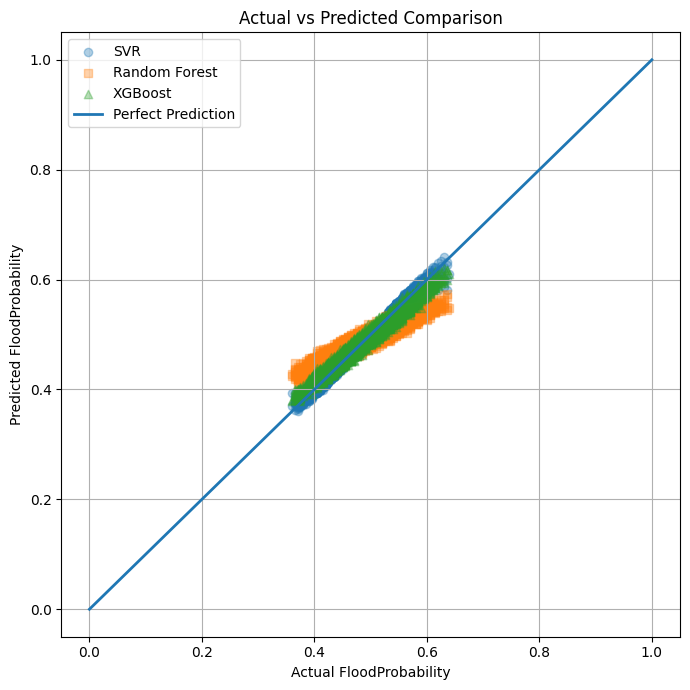

In [33]:
# ------------------------------------------------------------
# Visual comparison of model predictions
# Points closer to diagonal line = better prediction
# ------------------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred_svr, alpha=0.35, label="SVR", marker="o")
plt.scatter(y_test, y_pred_rf, alpha=0.35, label="Random Forest", marker="s")
plt.scatter(y_test, y_pred_xgb, alpha=0.35, label="XGBoost", marker="^")

# Perfect prediction reference line
plt.plot([0,1],[0,1], linewidth=2, label="Perfect Prediction")

plt.xlabel("Actual FloodProbability")
plt.ylabel("Predicted FloodProbability")
plt.title("Actual vs Predicted Comparison")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

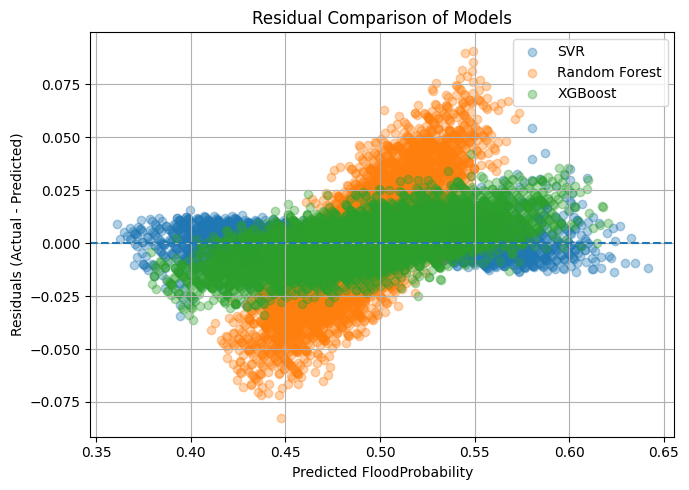

In [34]:
# ------------------------------------------------------------
# Residual Plot for SVR, Random Forest and XGBoost
# Residual = Actual - Predicted
# A good model shows random spread around 0 line
# ------------------------------------------------------------

import matplotlib.pyplot as plt

# Calculate residuals
res_svr = y_test - y_pred_svr
res_rf  = y_test - y_pred_rf
res_xgb = y_test - y_pred_xgb

plt.figure(figsize=(7,5))

# Plot residuals for each model
plt.scatter(y_pred_svr, res_svr, alpha=0.35, label="SVR")
plt.scatter(y_pred_rf,  res_rf,  alpha=0.35, label="Random Forest")
plt.scatter(y_pred_xgb, res_xgb, alpha=0.35, label="XGBoost")

# Reference horizontal line (perfect residual = 0)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted FloodProbability")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Comparison of Models")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()